In [1]:
import os
import numpy as np
import nibabel as nib
from nilearn import plotting
import seaborn as sns
from nilearn.maskers import NiftiLabelsMasker, NiftiMasker
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [2]:
load_dotenv()
base_dir = os.environ['BASE_DIR']
runs_str = "run-ON"

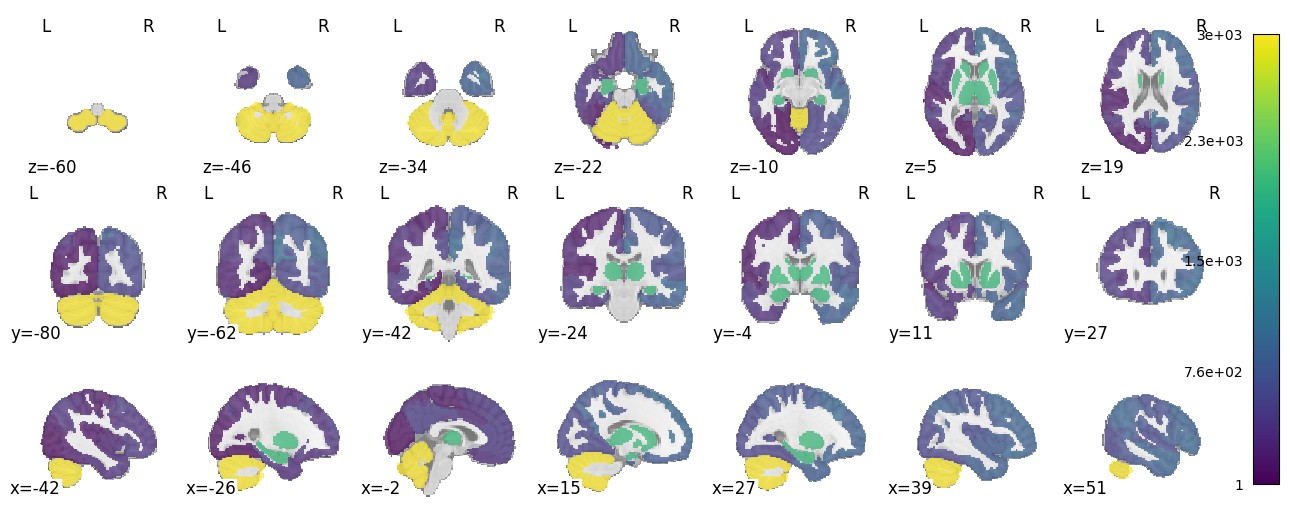

In [3]:
atlas_dir = os.environ['ATLAS_DIR']
atlas_filename = os.path.join(atlas_dir, "atlas_combined_tpl-MNI152NLin2009cAsym_res-02_T1w.nii.gz")
atlas_masker = NiftiLabelsMasker(labels_img=atlas_filename, mask_img=None, standardize=False, standardize_confounds=True, memory="nilearn_cache", verbose=0)
atlas_masker.fit()

plotting.plot_roi(atlas_filename, display_mode="mosaic", cmap="viridis",)

In [4]:
k=7
CAP_LIST = [f"CAP{i + 1}" for i in np.arange(k)]

results_dir = os.environ['RESULTS_DIR']
results_fig_dir = os.path.join(results_dir, "main_figures", "02_cosine_similarity_fig")

os.makedirs(results_fig_dir, exist_ok=True)

# Load CAP data
cap_file = os.path.join(base_dir, f'coactivation_patterns_{runs_str}',
                            f'caps_nclust-{k}', f'CAPcenter_paired_nclust-{k}.nii.gz')
cap_img = nib.load(cap_file)

# Transform data using masker
cap_data_masked = atlas_masker.transform(cap_img)  # Will be (n_caps, n_voxels)

## Cosine similarity

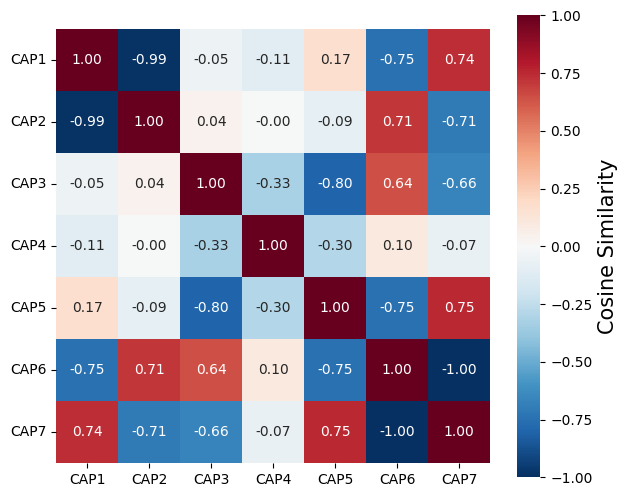

In [5]:
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.cm as cm

corr_mat = cosine_similarity(cap_data_masked)

fig, ax = plt.subplots(figsize=(7, 6))

heatmap = sns.heatmap(corr_mat, cmap="RdBu_r", vmax=1, vmin=-1, center=0,
                square=True, annot=True, fmt=".2f", ax=ax)
cbar = heatmap.collections[0].colorbar
cbar.set_label("Cosine Similarity", rotation=90, fontsize=15)

ax.set_xticklabels(CAP_LIST, rotation=0)
ax.set_yticklabels(CAP_LIST, rotation=0)
#ax.set_title("Cosine Similarity Matrix")
plt.savefig(os.path.join(results_fig_dir, f"cosine_corr_mat_nclust-{k}_with_labels"), dpi=500, bbox_inches='tight')
plt.show()

## Cosine similarity figure 

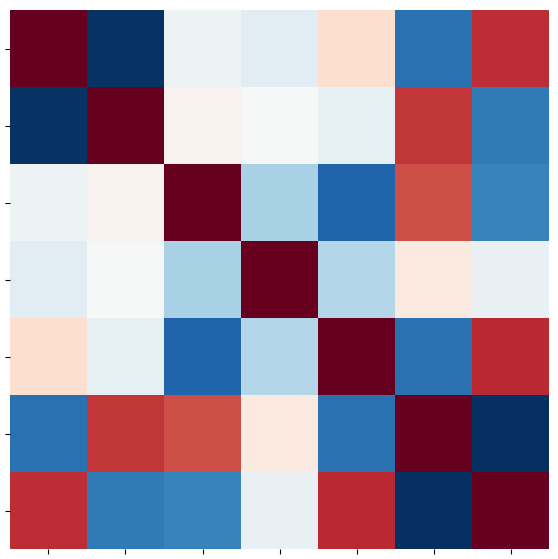

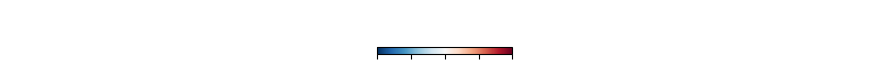

In [6]:
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.cm as cm

cmap = "RdBu_r"  
empty_labels = ["", "", "", "", "", "", ""]

corr_mat = cosine_similarity(cap_data_masked)

# Create the heatmap without annotations and with viridis colormap
fig, ax = plt.subplots(figsize=(7, 7))

heatmap = sns.heatmap(corr_mat, cmap=cmap, vmax=1, vmin=-1, center=0,
                square=True, annot=False, ax=ax, cbar=False)

ax.set_xticklabels(empty_labels)
ax.set_yticklabels(empty_labels)

# Save the main heatmap
plt.savefig(os.path.join(results_fig_dir, f"cosine_corr_mat_nclust-{k}"), dpi=500, bbox_inches='tight')

# Create separate legend/colorbar
fig_legend, ax_legend = plt.subplots(figsize=(9, 0.75))
ax_legend.axis('off')

# Create a colorbar manually
from matplotlib.colors import Normalize
import matplotlib.cm as cm

norm = Normalize(vmin=-1, vmax=1)
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax_legend, orientation='horizontal')
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
cbar.set_ticklabels(["", "", "", "", ""])
cbar.ax.tick_params(labelsize=42)
cbar.set_label('', fontsize=20)
plt.tight_layout()

# Save the legend separately
plt.savefig(os.path.join(results_fig_dir, f"cosine_corr_mat_legend_nclust-{k}"), dpi=500, bbox_inches='tight')